## Importing libraries

In [2]:
### Data Manipulation

import numpy as np
import pandas as pd


# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

# PCA for visualization
from sklearn.decomposition import PCA


## 2. Loading Datasets

In [3]:
# Loading Datasets of country

df = pd.read_csv("Country-data.csv")
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Datasets overview

In [4]:
df.tail(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310
166,Zambia,83.1,37.0,5.89,30.9,3280,14.00,52.0,5.40,1460


In [5]:
print(df.shape)

df.info()

(167, 10)
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### Missing Values

In [7]:
#count missing values
df.isnull().sum()
# Good
# No preprocessing required.

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### checking duplicate values

In [9]:
df.duplicated().sum()

#No need to remove duplicate records

np.int64(0)

In [10]:
df.dtypes

country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [11]:
# since only country feature is categorical column  but clustering only works with numerical data

X = df.drop("country",axis=1)

In [14]:
X  # contains only numerical feautures except country

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


## Correlation Heatmap

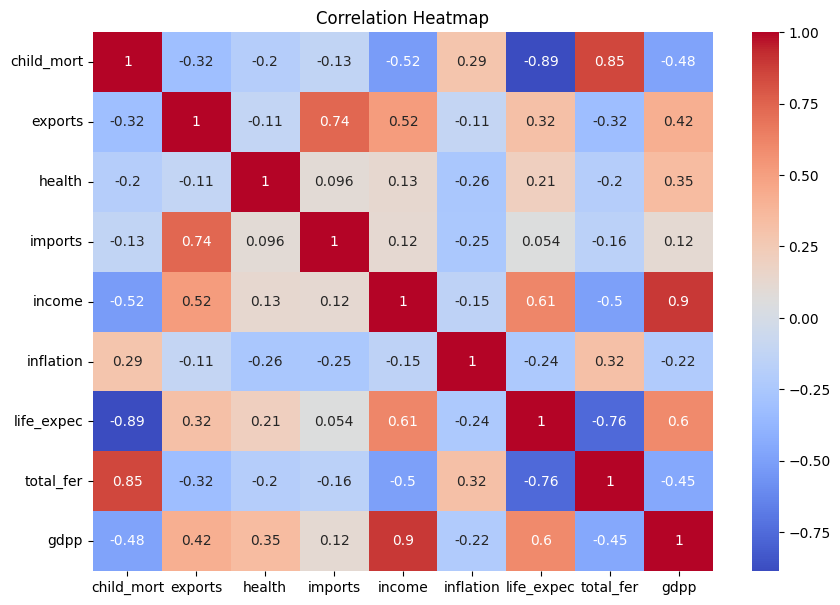

In [15]:
plt.figure(figsize=(10,7))

sns.heatmap(X.corr() , annot=True , cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

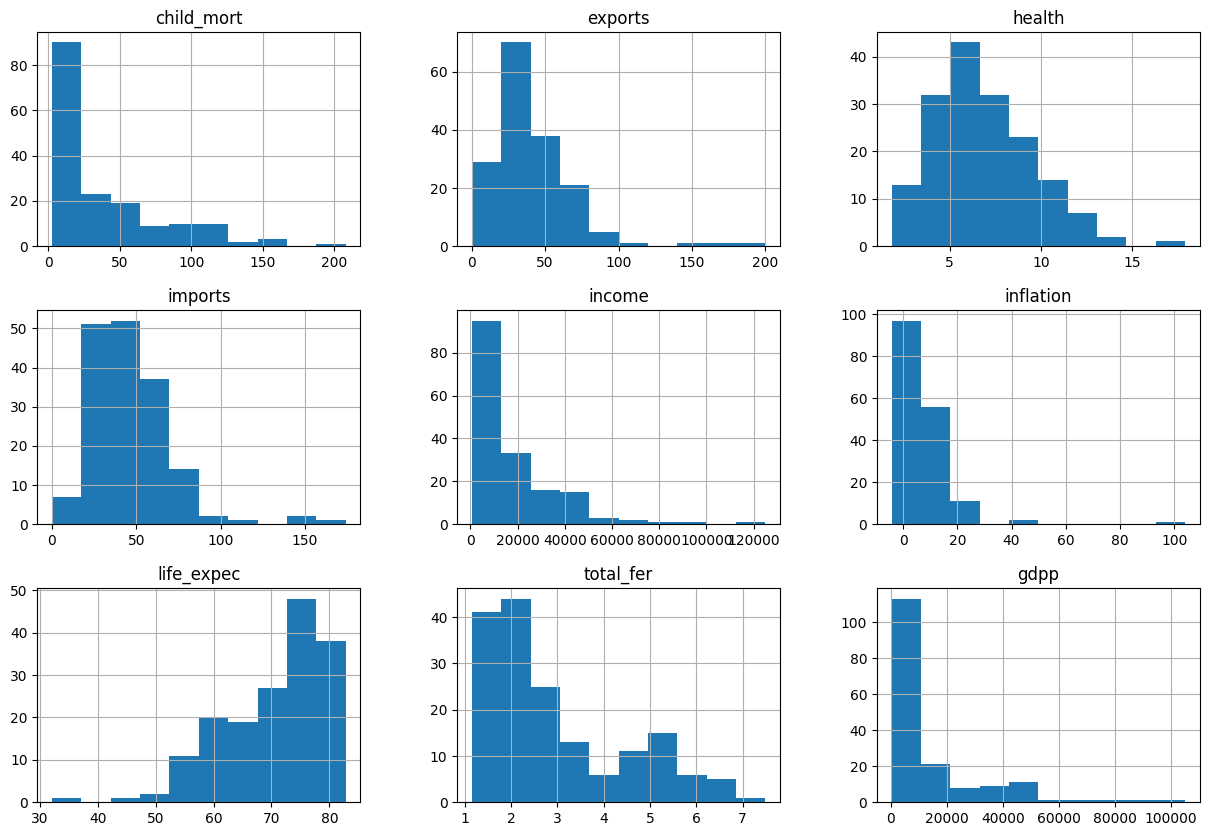

In [16]:
X.hist(figsize=(15,10))

plt.show()

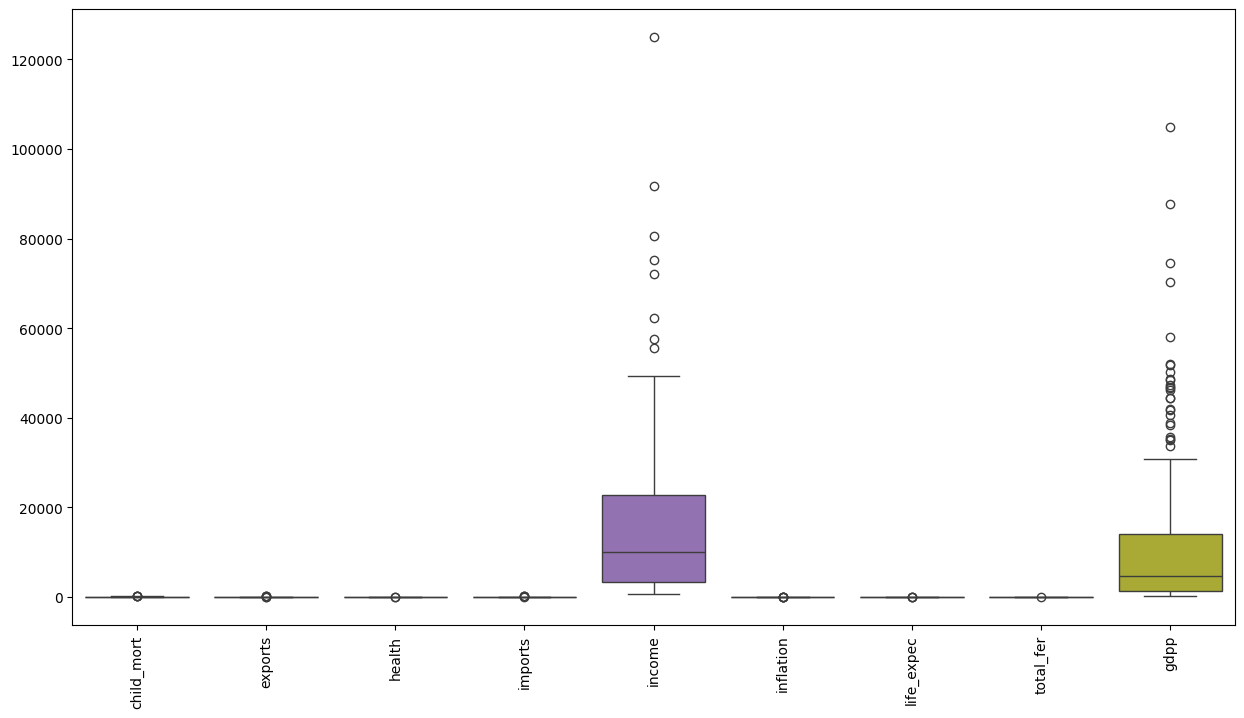

In [17]:
plt.figure(figsize=(15,8))

sns.boxplot(data=X)

plt.xticks(rotation=90)

plt.show()

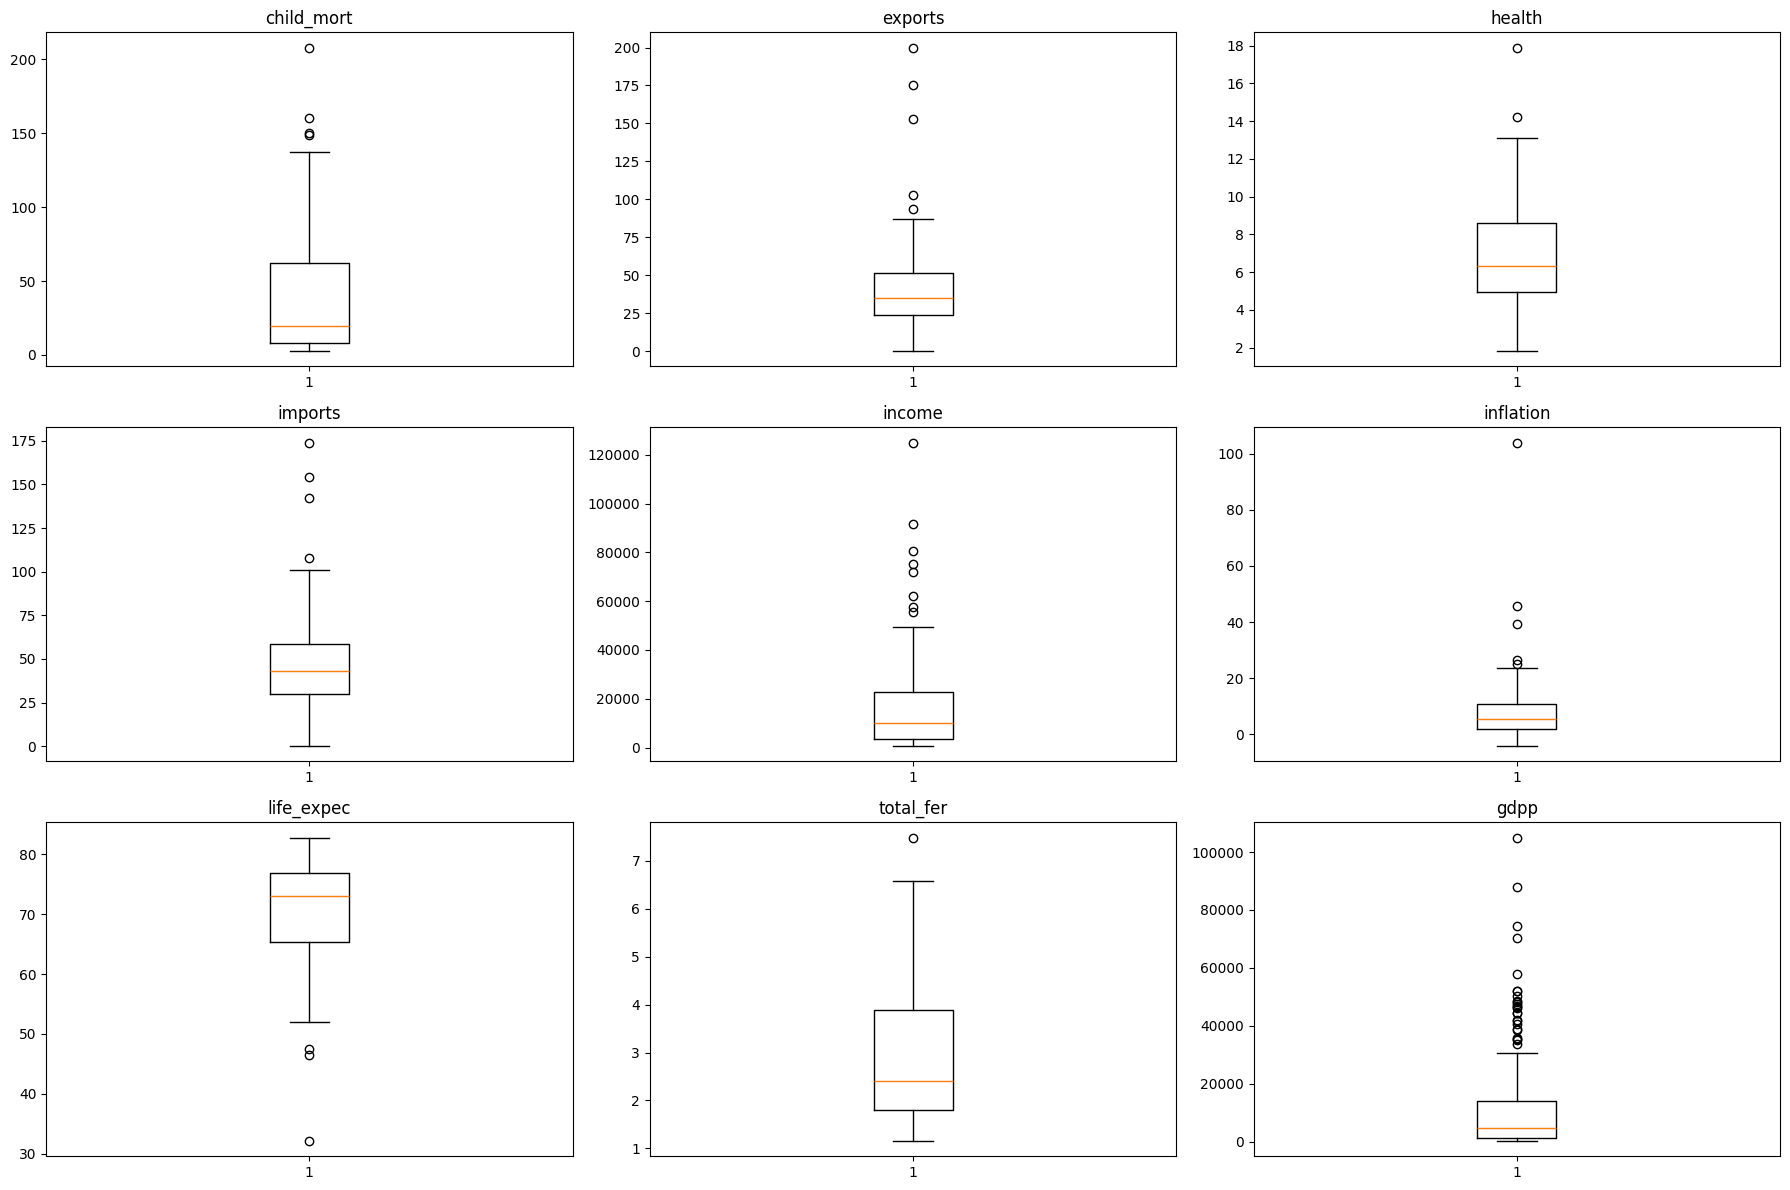

In [18]:


# Numerical columns only
num_cols = df.drop("country", axis=1).columns

plt.figure(figsize=(18,12))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [19]:
# Checking number of outliers in each feature

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col:15} --> {len(outliers)} Outliers")

child_mort      --> 4 Outliers
exports         --> 5 Outliers
health          --> 2 Outliers
imports         --> 4 Outliers
income          --> 8 Outliers
inflation       --> 5 Outliers
life_expec      --> 3 Outliers
total_fer       --> 1 Outliers
gdpp            --> 25 Outliers


In [20]:
# there is nearly few outliers so not necessary to remove it cuz
""" 
### For the Country dataset, the answer is generally No.

    Reason:

    Countries like

    Luxembourg
    Norway
    Switzerland

    naturally have high GDP and income.

    Countries like

    Somalia
    Chad
    Niger

    naturally have high child mortality.

    These are real observations, not errors.

    Therefore:

# We will NOT remove outliers.
"""

' \n### For the Country dataset, the answer is generally No.\n\n    Reason:\n\n    Countries like\n\n    Luxembourg\n    Norway\n    Switzerland\n\n    naturally have high GDP and income.\n\n    Countries like\n\n    Somalia\n    Chad\n    Niger\n\n    naturally have high child mortality.\n\n    These are real observations, not errors.\n\n    Therefore:\n\n# We will NOT remove outliers.\n'

### Standardize the datasets cuz income values dominate others

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


In [22]:
X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))

In [23]:
### verifying standardization

scaled_df = pd.DataFrame(X_scaled,columns= X.columns)
scaled_df.head(5)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [25]:
## expected meand is 0 and std is 1 

scaled_df.mean()

child_mort   -3.722904e-17
exports       2.127373e-16
health        5.504579e-16
imports       2.765585e-16
income       -7.977650e-17
inflation    -1.063687e-17
life_expec    3.696311e-16
total_fer     3.044803e-16
gdpp          5.850277e-17
dtype: float64

In [26]:
scaled_df.std()


child_mort    1.003008
exports       1.003008
health        1.003008
imports       1.003008
income        1.003008
inflation     1.003008
life_expec    1.003008
total_fer     1.003008
gdpp          1.003008
dtype: float64

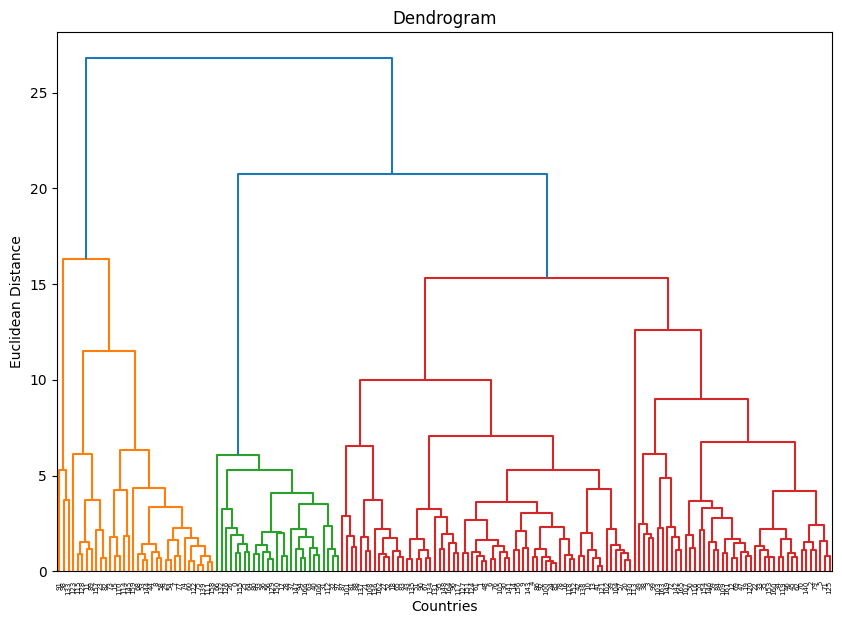

In [28]:
plt.figure(figsize=(10,7))
import scipy.cluster.hierarchy as agcl

plt.title("Country Dendron")
dend = agcl.dendrogram(agcl.linkage(X_scaled,method='ward'))
plt.title("Dendrogram")

plt.xlabel("Countries")

plt.ylabel("Euclidean Distance")

plt.show()